# Your First Emissions Tracking

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mlco2/codecarbon/blob/master/docs/tutorials/first-tracking.ipynb)

This tutorial walks you through tracking your first carbon emissions with CodeCarbon.
By the end, you will have:

1. Installed CodeCarbon
2. Tracked emissions from a simple computation
3. Inspected the results

---

## Step 1: Install CodeCarbon

In [38]:
!pip install codecarbon

## Step 2: Track emissions from a computation

The simplest way to use CodeCarbon is as a **context manager**. Everything inside the `with` block is tracked.

In [39]:
import time
import random
import pandas as pd
import matplotlib.pyplot as plt

from codecarbon import EmissionsTracker

with EmissionsTracker(project_name="my-first-tracking") as tracker:
    # Simulate some computation
    total = 0
    for i in range(10_000_000):
        total += i

print(f"Computation result: {total}")

[codecarbon INFO @ 17:34:14] Emissions data (if any) will be saved to file /content/emissions.csv
[codecarbon INFO @ 17:34:14] >>> Tracker's metadata:
[codecarbon INFO @ 17:34:14]   Platform system: Linux-6.6.122+-x86_64-with-glibc2.39
[codecarbon INFO @ 17:34:14]   Python version: 3.13.15
[codecarbon INFO @ 17:34:14]   CodeCarbon version: 3.3.1
[codecarbon INFO @ 17:34:14]   Available RAM : 12.671 GB
[codecarbon INFO @ 17:34:14]   CPU count: 2 thread(s) in 1 physical CPU(s)
[codecarbon INFO @ 17:34:14]   CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz
[codecarbon INFO @ 17:34:14]   GPU count: 0
[codecarbon INFO @ 17:34:14]   GPU model: 
[codecarbon INFO @ 17:34:14] Energy consumed for RAM : 0.000000 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 17:34:14] Delta energy consumed for CPU with cpu_load : 0.000000 kWh, power : 0.8173239488 W
[codecarbon INFO @ 17:34:14] Energy consumed for All CPU : 0.000000 kWh
[codecarbon INFO @ 17:34:14] 0.000000 kWh of electricity and 0.000000 L of water were us

Computation result: 49999995000000


## Step 3: Inspect the results

CodeCarbon saved the emissions data to a CSV file. Let's take a look:

In [40]:
import pandas as pd

df = pd.read_csv("emissions.csv")
df[["project_name", "duration", "emissions", "emissions_rate", "cpu_power", "ram_power", "energy_consumed"]]

,project_name,duration,emissions,emissions_rate,cpu_power,ram_power,energy_consumed
0,my-first-tracking,6.739396,4.468265e-06,6.630068e-07,7.977049,10.0,0.000032
1,my-first-tracking,4.636920,2.620498e-06,5.651378e-07,6.553531,10.0,0.000019
2,my-first-tracking,1.866095,8.291996e-07,4.443501e-07,1.684359,10.0,0.000006
3,my-first-tracking,1.657351,6.655227e-07,4.015581e-07,1.087062,10.0,0.000005
4,my-first-tracking,3.832826,2.275572e-06,5.937061e-07,3.482572,10.0,0.000016
5,my-first-tracking,3.185431,1.744799e-06,5.477436e-07,3.050563,10.0,0.000013


You can also access the emissions data directly from the tracker object:

In [41]:
print(f"Total emissions: {tracker.final_emissions * 1000:.4f} g CO2eq")
print(f"Duration: {tracker.final_emissions_data.duration:.2f} seconds")
print(f"Energy consumed: {tracker.final_emissions_data.energy_consumed:.6f} kWh")

Total emissions: 0.0017 g CO2eq
Duration: 3.19 seconds
Energy consumed: 0.000013 kWh


In [43]:
def linear_search(arr, target):
    for i, value in enumerate(arr):
        if value == target:
            return i
    return -1


def binary_search(arr, target):
    left = 0
    right = len(arr) - 1

    while left <= right:
        mid = (left + right) // 2

        if arr[mid] == target:
            return mid
        elif arr[mid] < target:
            left = mid + 1
        else:
            right = mid - 1

    return -1

In [47]:
input_sizes = [10_000, 50_000, 100_000, 500_000, 1_000_000]

# Repeat the search enough times to make energy consumption measurable
REPETITIONS = 1000

results = []

In [48]:
for n in input_sizes:

    data = list(range(n))
    target = n - 1

    print(f"Running n = {n:,}...")

    # -------------------------
    # Linear Search
    # -------------------------
    tracker = EmissionsTracker(
        project_name=f"Linear Search n={n}",
        save_to_file=False,
        log_level="error"
    )

    tracker.start()
    start = time.perf_counter()

    for _ in range(REPETITIONS):
        linear_search(data, target)

    linear_runtime = time.perf_counter() - start
    linear_emissions = tracker.stop()


    # -------------------------
    # Binary Search
    # -------------------------
    tracker = EmissionsTracker(
        project_name=f"Binary Search n={n}",
        save_to_file=False,
        log_level="error"
    )

    tracker.start()
    start = time.perf_counter()

    for _ in range(REPETITIONS):
        binary_search(data, target)

    binary_runtime = time.perf_counter() - start
    binary_emissions = tracker.stop()


    results.append({
        "Input Size": n,
        "Linear Runtime": linear_runtime,
        "Linear CO2e": linear_emissions,
        "Binary Runtime": binary_runtime,
        "Binary CO2e": binary_emissions
    })

scaling_df = pd.DataFrame(results)

scaling_df

Running n = 10,000...
Running n = 50,000...
Running n = 100,000...
Running n = 500,000...
Running n = 1,000,000...


,Input Size,Linear Runtime,Linear CO2e,Binary Runtime,Binary CO2e
0,10000,2.804051,0.000002,0.019164,2.331586e-09
1,50000,6.249702,0.000004,0.002959,1.263060e-10
2,100000,7.651043,0.000004,0.005300,3.432033e-10
3,500000,39.802363,0.000017,0.006622,1.175196e-10
4,1000000,74.029555,0.000035,0.003808,1.567224e-10


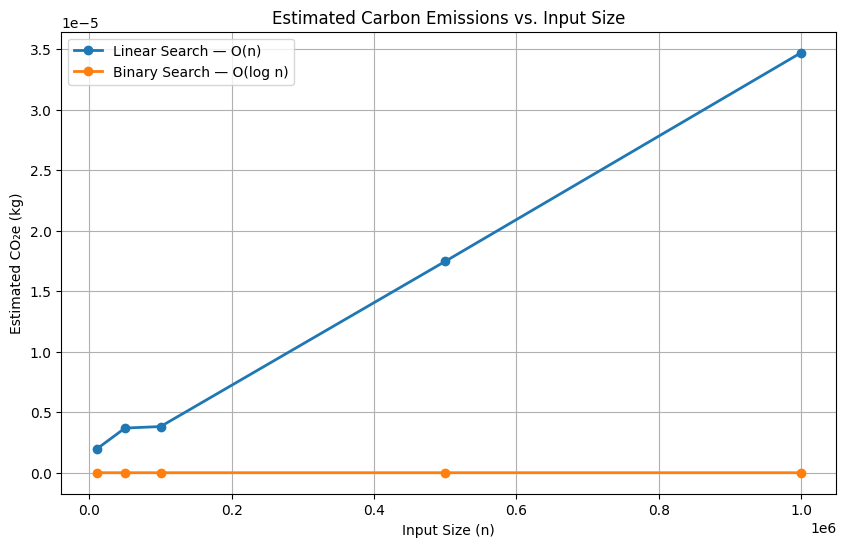

In [49]:
plt.figure(figsize=(10, 6))

plt.plot(
    scaling_df["Input Size"],
    scaling_df["Linear CO2e"],
    marker="o",
    linewidth=2,
    label="Linear Search — O(n)"
)

plt.plot(
    scaling_df["Input Size"],
    scaling_df["Binary CO2e"],
    marker="o",
    linewidth=2,
    label="Binary Search — O(log n)"
)

plt.xlabel("Input Size (n)")
plt.ylabel("Estimated CO₂e (kg)")
plt.title("Estimated Carbon Emissions vs. Input Size")
plt.legend()
plt.grid(True)

plt.show()

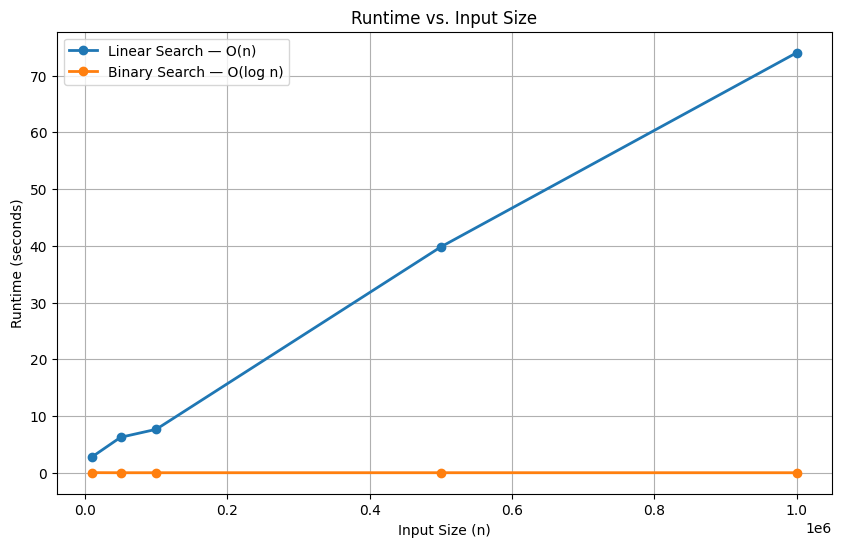

In [50]:
plt.figure(figsize=(10, 6))

plt.plot(
    scaling_df["Input Size"],
    scaling_df["Linear Runtime"],
    marker="o",
    linewidth=2,
    label="Linear Search — O(n)"
)

plt.plot(
    scaling_df["Input Size"],
    scaling_df["Binary Runtime"],
    marker="o",
    linewidth=2,
    label="Binary Search — O(log n)"
)

plt.xlabel("Input Size (n)")
plt.ylabel("Runtime (seconds)")
plt.title("Runtime vs. Input Size")
plt.legend()
plt.grid(True)

plt.show()

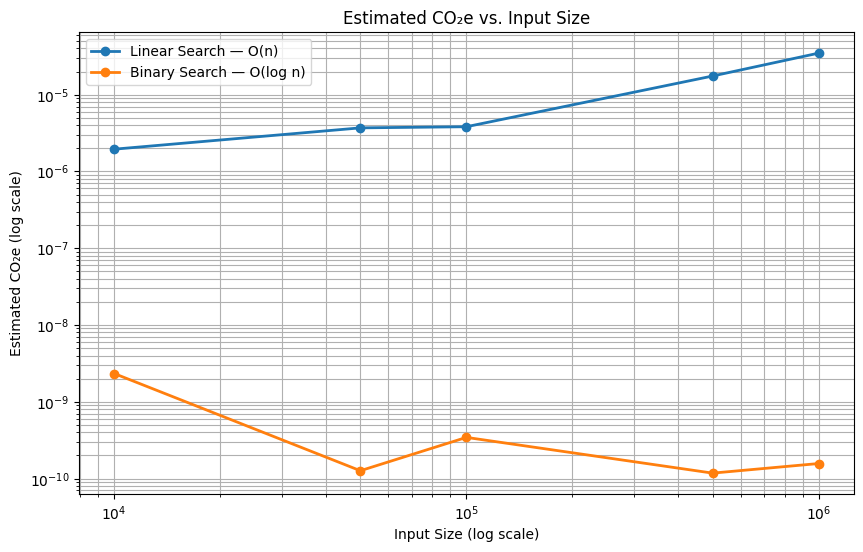

In [51]:
plt.figure(figsize=(10, 6))

plt.plot(
    scaling_df["Input Size"],
    scaling_df["Linear CO2e"],
    marker="o",
    linewidth=2,
    label="Linear Search — O(n)"
)

plt.plot(
    scaling_df["Input Size"],
    scaling_df["Binary CO2e"],
    marker="o",
    linewidth=2,
    label="Binary Search — O(log n)"
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Input Size (log scale)")
plt.ylabel("Estimated CO₂e (log scale)")
plt.title("Estimated CO₂e vs. Input Size")
plt.legend()
plt.grid(True, which="both")

plt.show()

## What's next?

- Try the [CodeCarbon Workshop notebook](https://github.com/mlco2/codecarbon/blob/master/examples/notebooks/codecarbon_workshop.ipynb) for a comprehensive hands-on experience
- Learn about [CLI tracking](cli.md) to monitor without code changes
- Explore all [Python API options](python-api.md) (decorators, explicit objects, offline mode)
- See the full [API Reference](../reference/api.md) for all configuration parameters